In [1]:
import pandas as pd

from src.gp.engine import GPConfig, ramped_half_and_half, random_tree


grow-only  | 深度 2~6 (均值3.7) | 节点数 3~25 (均值7.1)
ramped     | 深度 1~6 (均值3.0) | 节点数 2~41 (均值7.0)


<Axes: >

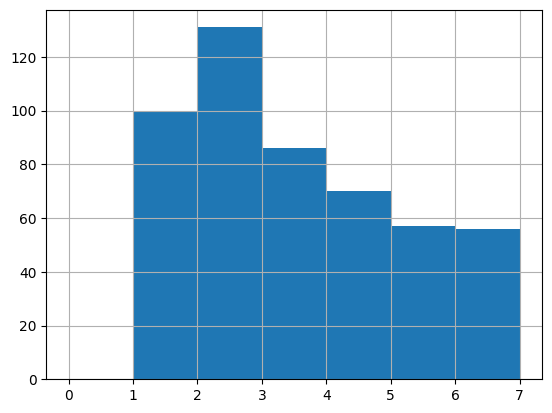

In [2]:
cfg = GPConfig()
grow_only = [random_tree(cfg.max_depth, cfg.min_depth) for _ in range(500)]
ramped = ramped_half_and_half(500, cfg.min_depth, cfg.max_depth)


def describe(pop, name):
    d = pd.Series([t.depth() for t in pop])
    s = pd.Series([t.size() for t in pop])
    print(
        f"{name:10s} | 深度 {d.min()}~{d.max()} (均值{d.mean():.1f}) "
        f"| 节点数 {s.min()}~{s.max()} (均值{s.mean():.1f})"
    )


describe(grow_only, "grow-only")
describe(ramped, "ramped")

# 想看分布形状就画直方图：
pd.Series([t.depth() for t in ramped]).hist(bins=range(0, cfg.max_depth + 2))

In [1]:
import numpy as np
import pandas as pd

from src.evaluation.fitness import compute_forward_returns, make_fitness
from src.gp.engine import GPConfig, run_gp
from src.gp.evaluator import to_wide

# 复用之前的迷你合成数据（20 只 × 60 天）
dates = pd.date_range("2024-01-01", periods=60, freq="B")
codes = [f"s{i:02d}" for i in range(20)]
idx = pd.MultiIndex.from_product([dates, codes], names=["date", "code"])
rng = np.random.default_rng(0)
prices = pd.DataFrame(
    {
        c: rng.random(len(idx)) * 100 + 10
        for c in ["open", "high", "low", "close", "volume", "amount"]
    },
    index=idx,
)
wide = to_wide(prices)
fwd = compute_forward_returns(wide["close"], period=5)

cfg = GPConfig(population_size=40, generations=8, max_depth=6, min_depth=2)

for alpha in [0.0, 0.005]:
    fn = make_fitness(wide, fwd, parsimony=alpha)
    best_tree, best_score = run_gp(fn, cfg)[0]
    print(f"α={alpha}: 最佳 size={best_tree.size():2d}  score={best_score:.4f}")


Gen   0 | best=3.1810 | mean=-0.0032 | expr=sub(high, close)
Gen   1 | best=3.6294 | mean=0.7422 | expr=add(delta(close), close)
Gen   2 | best=4.3691 | mean=1.7059 | expr=close
Gen   3 | best=4.3691 | mean=2.6137 | expr=close
Gen   4 | best=4.3691 | mean=4.1442 | expr=close
Gen   5 | best=4.3691 | mean=4.2621 | expr=close
Gen   6 | best=4.3691 | mean=4.3524 | expr=close
Gen   7 | best=4.3691 | mean=4.3691 | expr=close
α=0.0: 最佳 size= 1  score=4.3691
Gen   0 | best=4.3441 | mean=0.0383 | expr=sub(add(close, amount), amount)
Gen   1 | best=4.3441 | mean=1.2578 | expr=sub(add(close, amount), amount)
Gen   2 | best=4.4057 | mean=2.3181 | expr=sub(div(amount, sub(close, div(log(low), neg(open)))), close)
Gen   3 | best=4.4057 | mean=3.7042 | expr=sub(div(amount, sub(close, div(log(low), neg(open)))), close)
Gen   4 | best=4.4357 | mean=3.3663 | expr=sub(div(amount, close), close)
Gen   5 | best=4.4357 | mean=3.2719 | expr=sub(div(amount, close), close)
Gen   6 | best=4.4509 | mean=3.5403 |